In [ ]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("shree0910/work-productivity-and-burnout-risk-dataset")
csv_file_path = os.path.join(path, "Work Productivity.csv")
df = pd.read_csv(csv_file_path)
df.info()

Using Colab cache for faster access to the 'work-productivity-and-burnout-risk-dataset' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              30000 non-null  int64  
 1   Age                      30000 non-null  int64  
 2   Gender                   30000 non-null  object 
 3   Country                  30000 non-null  object 
 4   Job_Role                 30000 non-null  object 
 5   Experience_Years         30000 non-null  int64  
 6   Company_Size             30000 non-null  object 
 7   Work_Hours_Per_Day       30000 non-null  float64
 8   Meetings_Per_Day         30000 non-null  int64  
 9   Internet_Speed_Mbps      30000 non-null  float64
 10  Work_Environment         30000 non-null  object 
 11  Sleep_Hours              30000 non-null  float64
 12  Exercise_Hours_Per_Week  30000 no

In [ ]:
#Verificação de variáveis nulas
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Country,0
Job_Role,0
Experience_Years,0
Company_Size,0
Work_Hours_Per_Day,0
Meetings_Per_Day,0
Internet_Speed_Mbps,0


In [ ]:
#Medidas de tendência central das variáveis numéricas
from IPython.display import display
cols = df.drop(columns=['Employee_ID', 'Internet_Speed_Mbps']).select_dtypes(include='number').columns

stats = pd.DataFrame({
    'Média': df[cols].mean(),
    'Mediana': df[cols].median(),
    'Moda': df[cols].mode().iloc[0],
    'Mínimo': df[cols].min(),
    'Máximo': df[cols].max(),
    'Desvio Padrão': df[cols].std(),
    'Q1': df[cols].quantile(0.25),
    'Q3': df[cols].quantile(0.75)
})

display(stats)

,Média,Mediana,Moda,Mínimo,Máximo,Desvio Padrão,Q1,Q3
Age,37.976967,38.0,32.0,22.0,54.0,9.523616,30.0,46.0
Experience_Years,8.011433,6.0,1.0,0.0,32.0,7.346979,2.0,12.0
Work_Hours_Per_Day,7.003800,7.0,5.9,4.0,10.0,1.730786,5.5,8.5
Meetings_Per_Day,3.518367,4.0,7.0,0.0,7.0,2.298689,1.0,6.0
Sleep_Hours,6.504893,6.5,7.0,4.0,9.0,1.440203,5.3,7.7
Exercise_Hours_Per_Week,2.998747,3.0,4.4,0.0,6.0,1.730969,1.5,4.5
Screen_Time_Hours,9.511867,9.5,5.8,5.0,14.0,2.591045,7.3,11.8
Productivity_Score,75.005400,76.0,100.0,30.0,100.0,17.117110,63.0,89.0


In [ ]:
#Definição das colunas numéricas que serão trabalhadas
colsNum = ["Work_Hours_Per_Day", "Meetings_Per_Day", "Sleep_Hours", "Exercise_Hours_Per_Week", "Screen_Time_Hours", "Productivity_Score"]

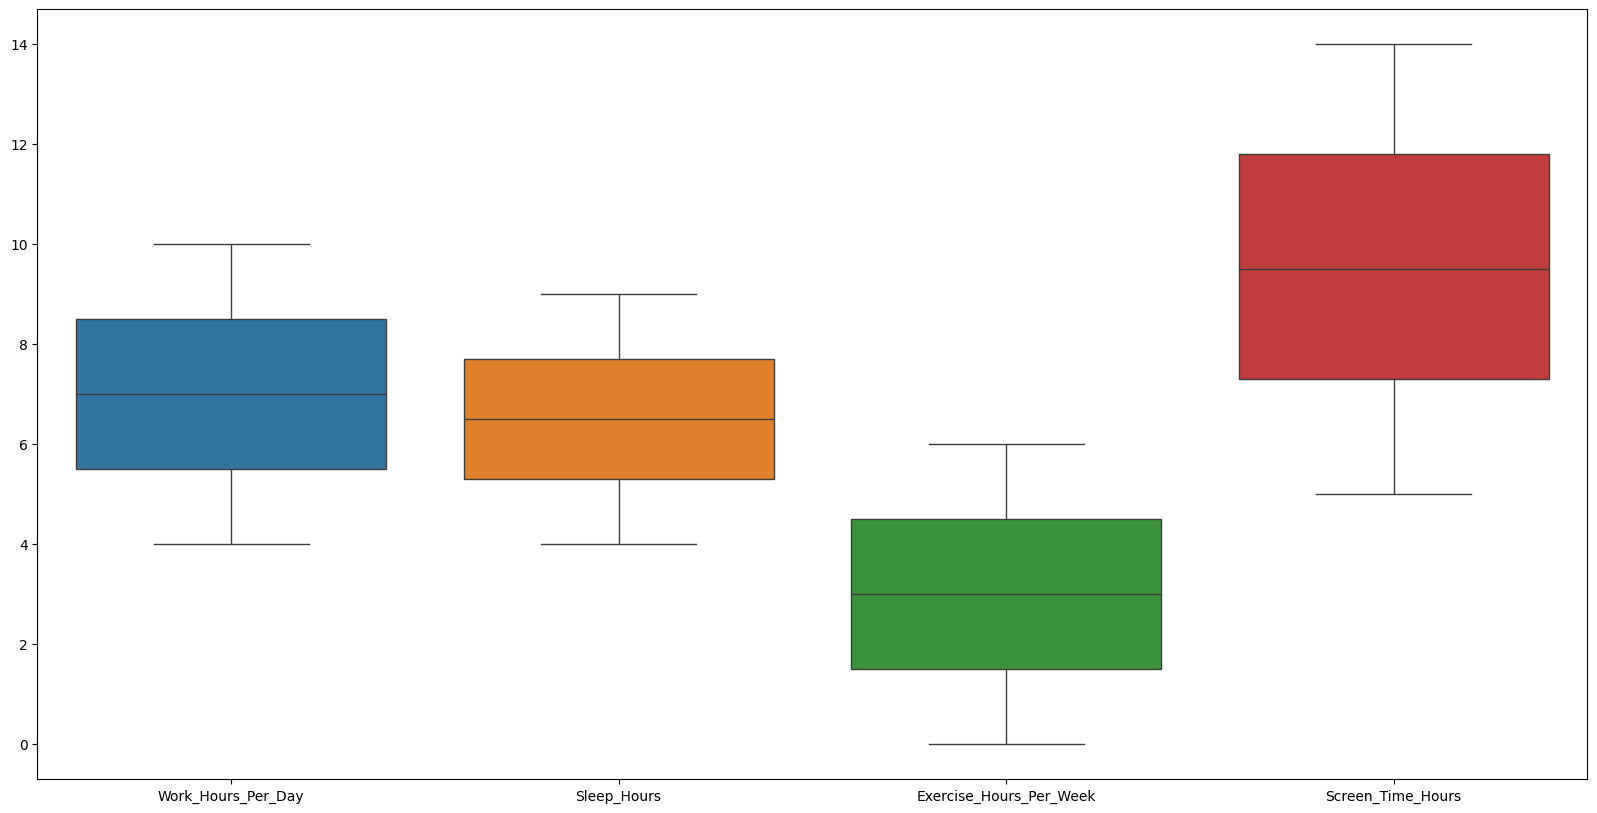

VERIFICANDO EXISTÊNCIA DE OUTLIERS

 Work_Hours_Per_Day:
   Q1: 5.50
   Q3: 8.50
   IQR: 3.00
   Limites: [1.00, 13.00]
   Mínimo: 4.00
   Máximo: 10.00
   Número de outliers: 0
   Nenhum outlier detectado!

 Sleep_Hours:
   Q1: 5.30
   Q3: 7.70
   IQR: 2.40
   Limites: [1.70, 11.30]
   Mínimo: 4.00
   Máximo: 9.00
   Número de outliers: 0
   Nenhum outlier detectado!

 Exercise_Hours_Per_Week:
   Q1: 1.50
   Q3: 4.50
   IQR: 3.00
   Limites: [-3.00, 9.00]
   Mínimo: 0.00
   Máximo: 6.00
   Número de outliers: 0
   Nenhum outlier detectado!

 Screen_Time_Hours:
   Q1: 7.30
   Q3: 11.80
   IQR: 4.50
   Limites: [0.55, 18.55]
   Mínimo: 5.00
   Máximo: 14.00
   Número de outliers: 0
   Nenhum outlier detectado!


In [ ]:
#Identificação de outliers (com boxplot)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[["Work_Hours_Per_Day", "Sleep_Hours", "Exercise_Hours_Per_Week", "Screen_Time_Hours"]],
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 6})
plt.show()

# Função para verificar outliers
def verificar_outliers(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"\n {coluna}:")
    print(f"   Q1: {Q1:.2f}")
    print(f"   Q3: {Q3:.2f}")
    print(f"   IQR: {IQR:.2f}")
    print(f"   Limites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"   Mínimo: {df[coluna].min():.2f}")
    print(f"   Máximo: {df[coluna].max():.2f}")
    print(f"   Número de outliers: {len(outliers)}")

    if len(outliers) > 0:
        print(f"   Valores outliers: {sorted(outliers[coluna].tolist())}")
    else:
        print(f"   Nenhum outlier detectado!")

    return outliers

# Verificar cada coluna
print("="*60)
print("VERIFICANDO EXISTÊNCIA DE OUTLIERS")
print("="*60)

colunas = ["Work_Hours_Per_Day", "Sleep_Hours", "Exercise_Hours_Per_Week", "Screen_Time_Hours"]

for col in colunas:
    verificar_outliers(df, col)


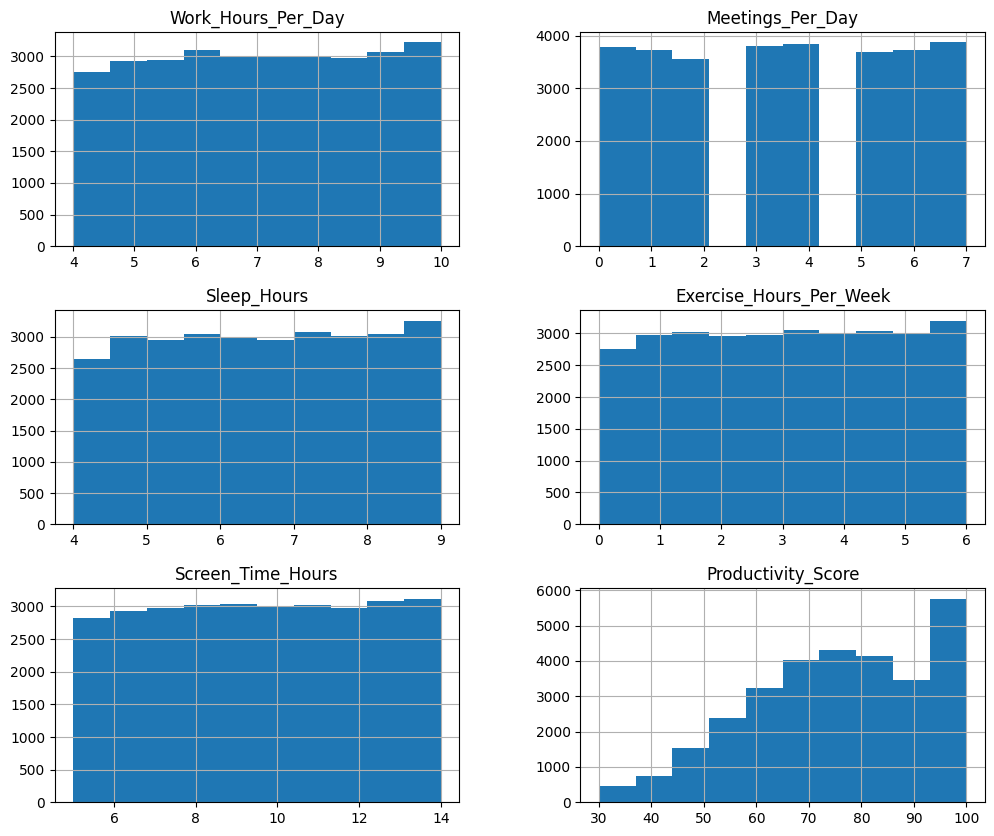

In [ ]:
#Histogramas
df[colsNum].hist(figsize=(12,10))
plt.show()

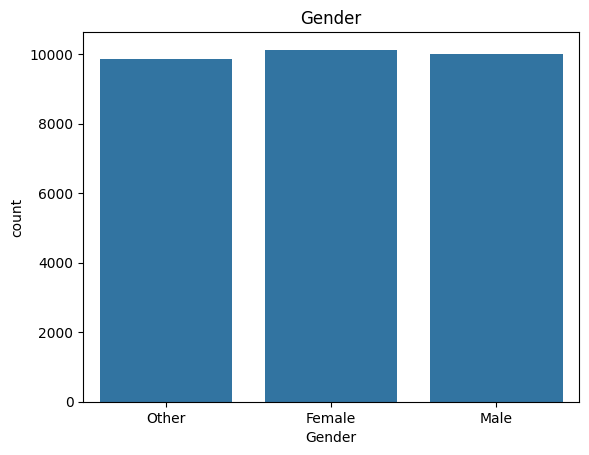

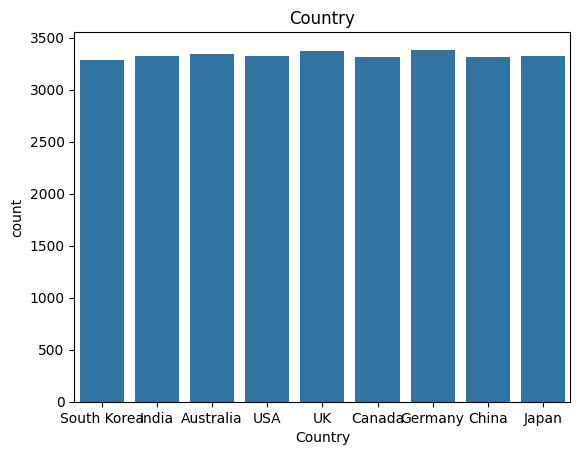

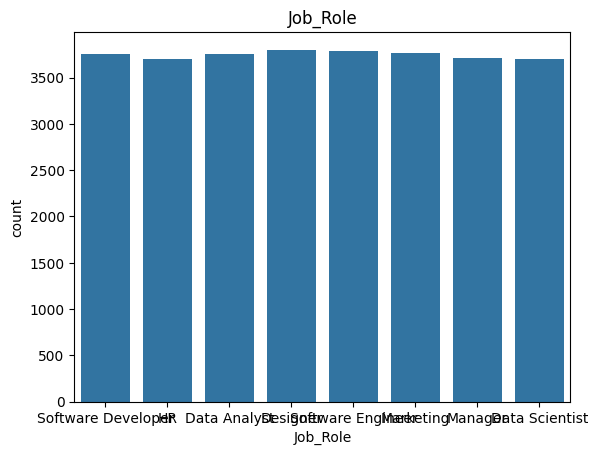

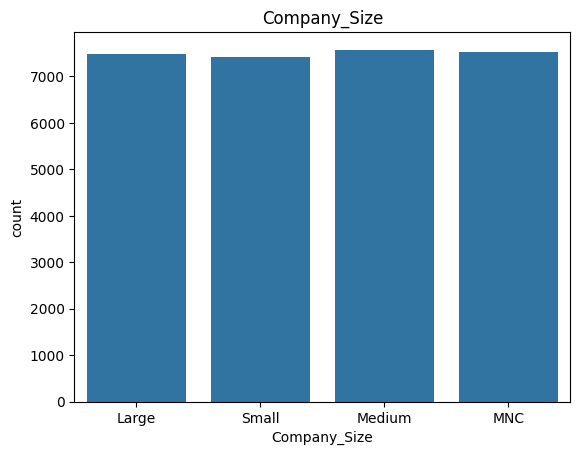

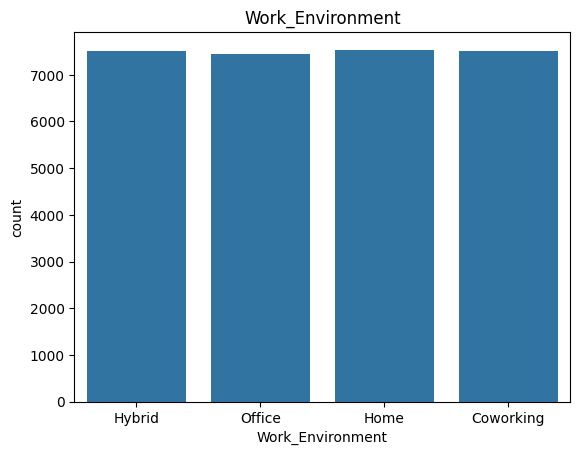

In [ ]:
#Distribuição de variáveis categóricas
colsCat = ["Gender", "Country", "Job_Role", "Company_Size", "Work_Environment"]

for col in colsCat:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

/tmp/ipykernel_40200/4194456814.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{percent[i]:.1f}%',


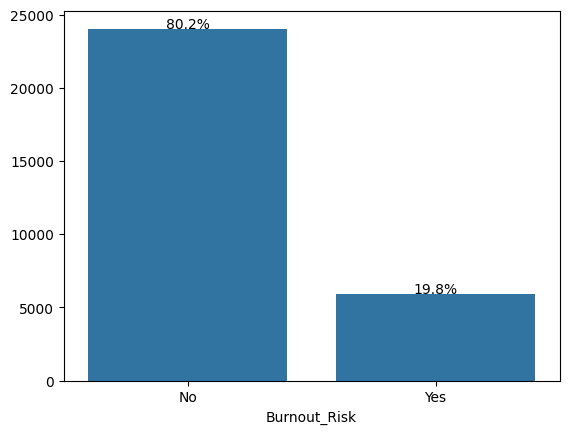

In [ ]:
#Desbalanceamento
counts = df["Burnout_Risk"].value_counts()
percent = df["Burnout_Risk"].value_counts(normalize=True) * 100

x = sns.barplot(x=counts.index, y=counts.values)
x.set_xticks([0,1])
x.set_xticklabels(["No", "Yes"])

for i, p in enumerate(x.patches):
    x.text(p.get_x() + p.get_width()/2,
            p.get_height(),
            f'{percent[i]:.1f}%',
            ha="center")

plt.show()

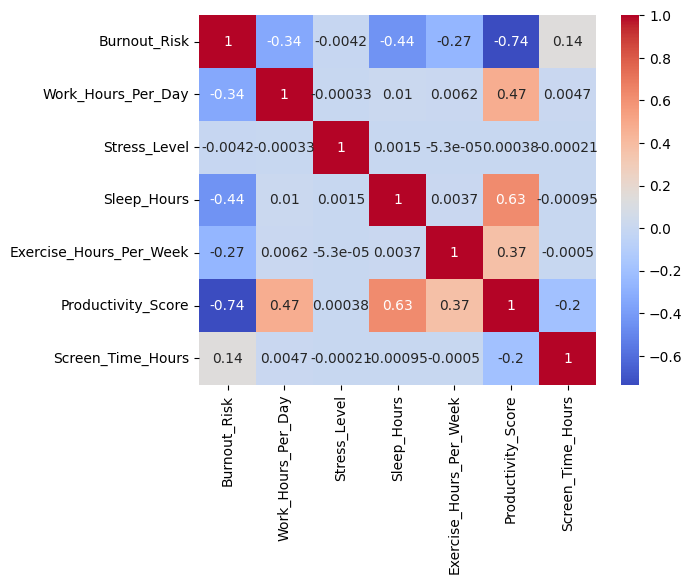

In [ ]:
#Mapa de calor de correlação
df["Burnout_Risk"] = (
    df["Burnout_Risk"]
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

df["Stress_Level"] = df["Stress_Level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

cols = ["Burnout_Risk", "Work_Hours_Per_Day", "Stress_Level", "Sleep_Hours", "Exercise_Hours_Per_Week", "Productivity_Score", "Screen_Time_Hours"]
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()